# Hotel Booking Cancellations - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/hotel_bookings_cleaned.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Cancellation rate: {df['is_canceled'].mean()*100:.1f}%")

Dataset: 86967 rows, 33 columns
Cancellation rate: 27.3%


---
## 1. Korelacja zmiennych z celem (is_canceled)

Które cechy najsilniej korelują z anulowaniem rezerwacji?

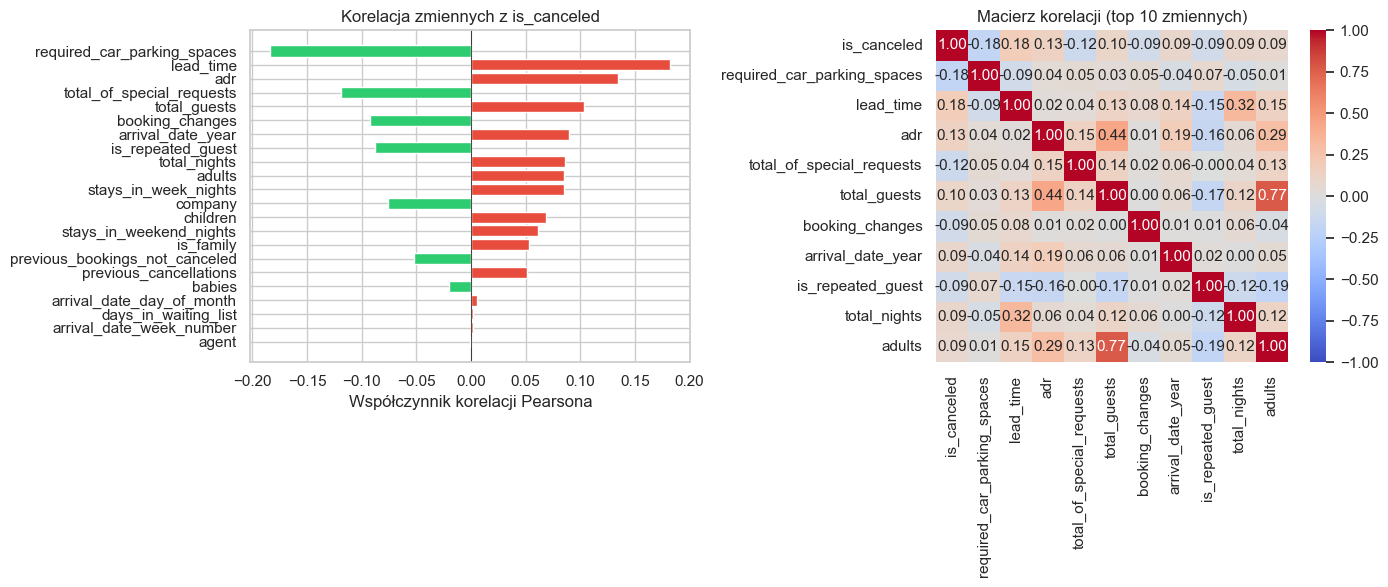


📊 Top 5 cech pozytywnie skorelowanych z anulowaniem:
  - lead_time: 0.182
  - adr: 0.134
  - total_guests: 0.103
  - arrival_date_year: 0.089
  - total_nights: 0.086

📊 Top 5 cech negatywnie skorelowanych z anulowaniem:
  - required_car_parking_spaces: -0.184
  - total_of_special_requests: -0.119
  - booking_changes: -0.092
  - is_repeated_guest: -0.088
  - company: -0.076


In [2]:
# Korelacja zmiennych numerycznych z is_canceled
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot korelacji
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations.values]
axes[0].barh(correlations.index, correlations.values, color=colors)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Współczynnik korelacji Pearsona')
axes[0].set_title('Korelacja zmiennych z is_canceled')
axes[0].invert_yaxis()

# Heatmapa top 10 zmiennych
top_features = ['is_canceled'] + list(correlations.head(10).index)
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1], center=0, vmin=-1, vmax=1)
axes[1].set_title('Macierz korelacji (top 10 zmiennych)')

plt.tight_layout()
plt.show()

print('\n📊 Top 5 cech pozytywnie skorelowanych z anulowaniem:')
for feat, corr in correlations[correlations > 0].head(5).items():
    print(f'  - {feat}: {corr:.3f}')

print('\n📊 Top 5 cech negatywnie skorelowanych z anulowaniem:')
for feat, corr in correlations[correlations < 0].head(5).items():
    print(f'  - {feat}: {corr:.3f}')

---
## 2. Rozkłady zmiennych numerycznych

Jak wyglądają rozkłady kluczowych zmiennych liczbowych?

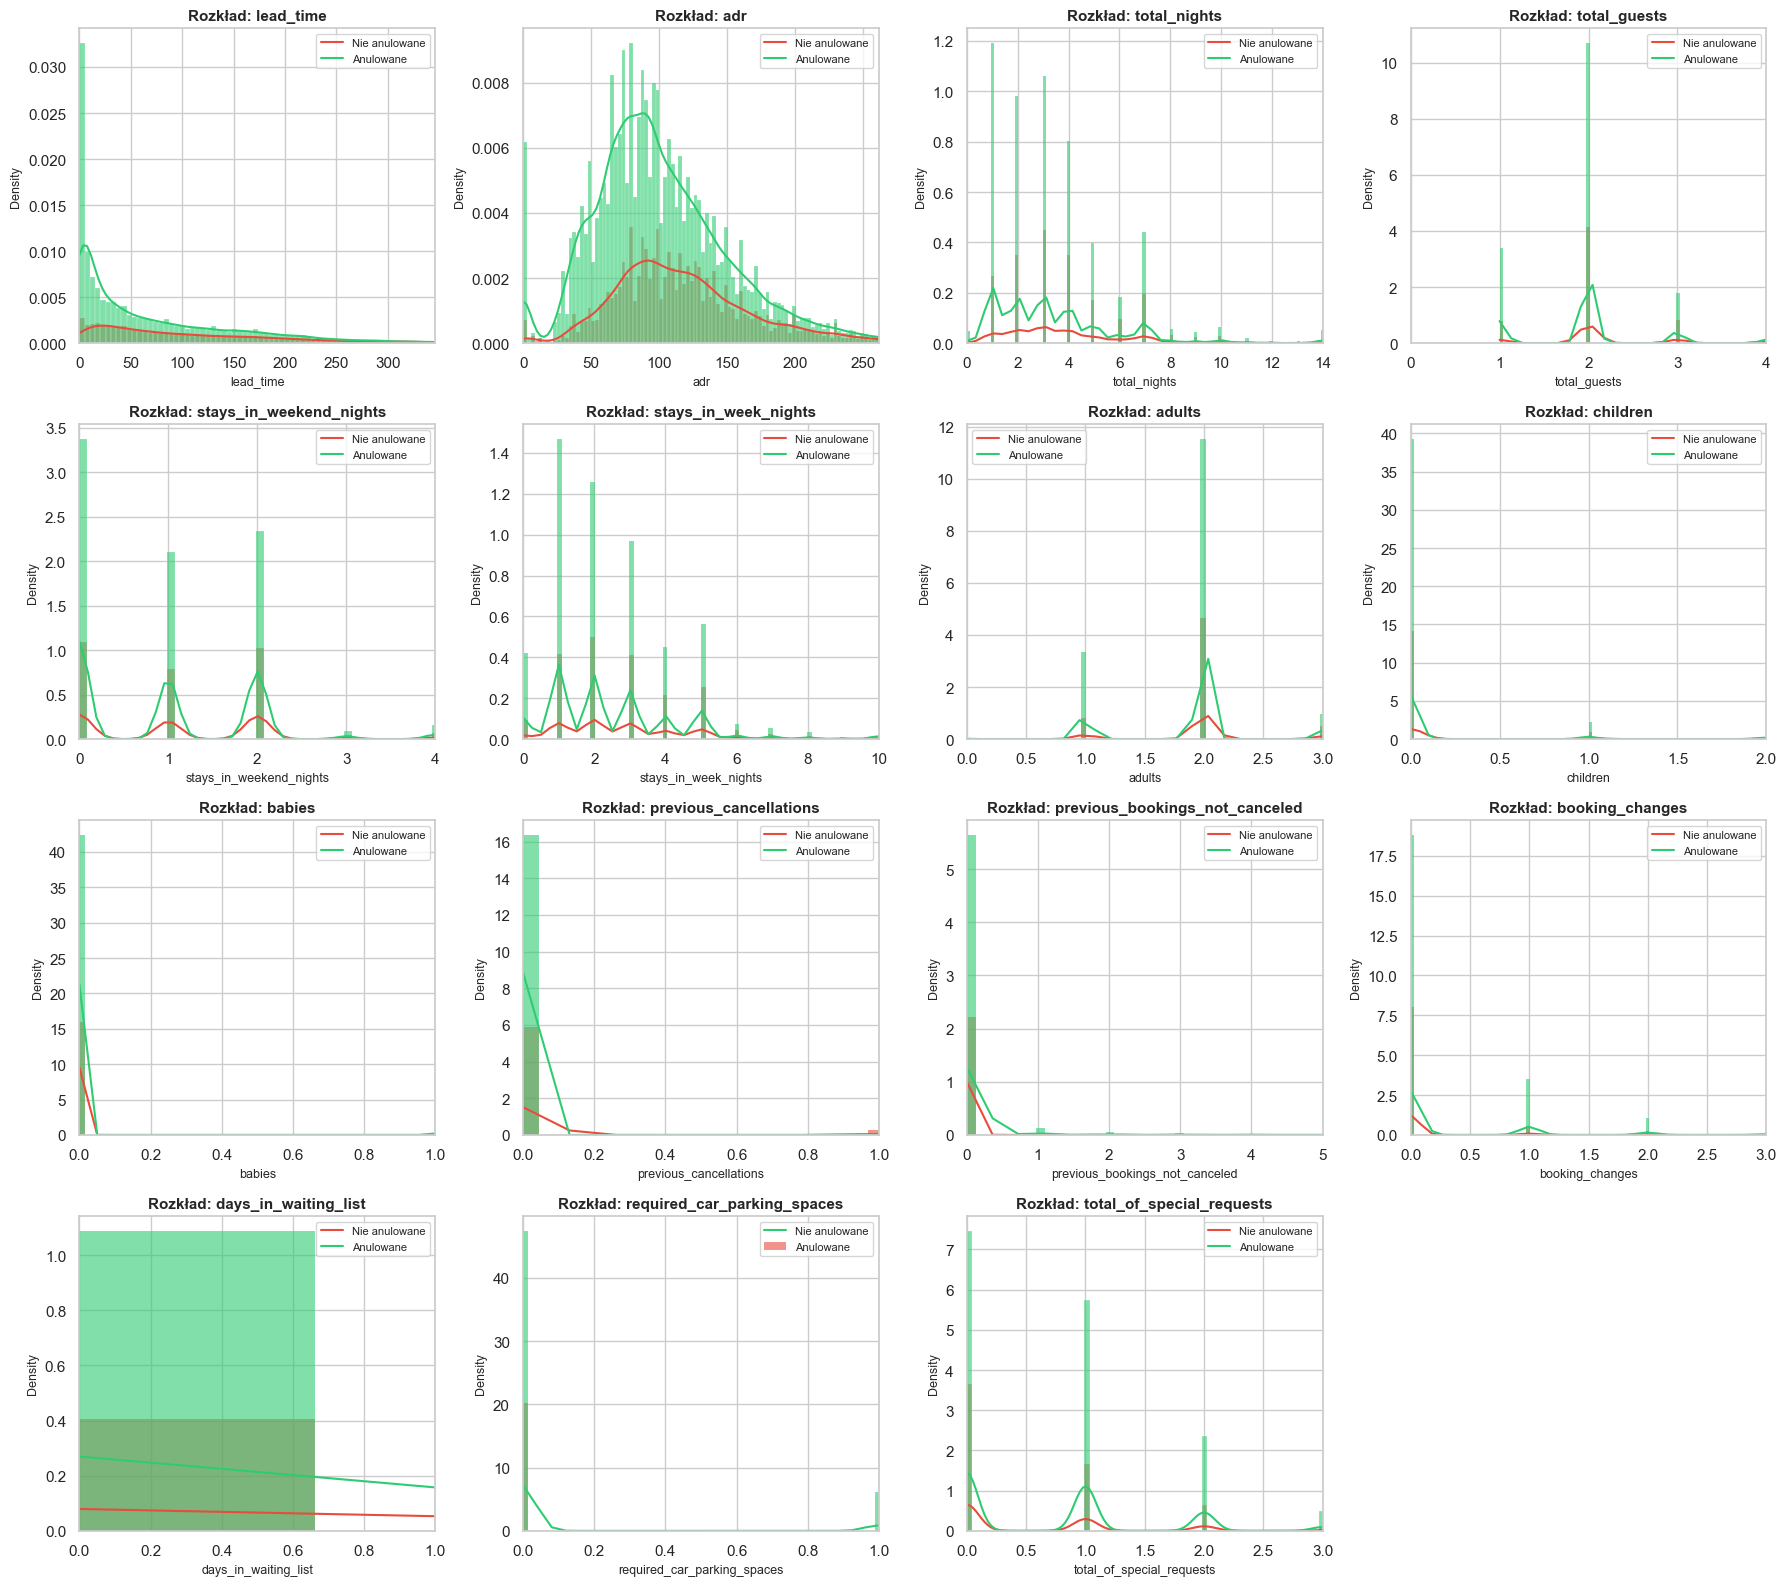


📊 Statystyki opisowe zmiennych numerycznych:


,lead_time,adr,total_nights,total_guests,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00,86967.00
mean,79.79,106.49,3.63,2.03,1.00,2.62,1.88,0.14,0.01,0.03,0.18,0.27,0.73,0.08,0.70
std,85.94,51.90,2.74,0.74,1.03,2.04,0.56,0.46,0.11,0.37,1.74,0.71,9.85,0.28,0.83
min,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,11.00,72.25,2.00,2.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,49.00,98.28,3.00,2.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,125.00,134.10,5.00,2.00,2.00,4.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,737.00,510.00,69.00,27.00,19.00,50.00,27.00,10.00,10.00,26.00,72.00,18.00,391.00,8.00,5.00


In [3]:
# Rozkłady WSZYSTKICH zmiennych numerycznych - z ograniczeniem osi dla lepszej widoczności
all_numeric = ['lead_time', 'adr', 'total_nights', 'total_guests', 
               'stays_in_weekend_nights', 'stays_in_week_nights',
               'adults', 'children', 'babies',
               'previous_cancellations', 'previous_bookings_not_canceled',
               'booking_changes', 'days_in_waiting_list', 
               'required_car_parking_spaces', 'total_of_special_requests']

# Limity osi (99 percentyl) aby outliers nie ściskały wykresów
xlims = {col: (0, max(df[col].quantile(0.99), 1)) for col in all_numeric}

# Oblicz liczbę wierszy potrzebnych (4 kolumny)
n_cols = 4
n_rows = (len(all_numeric) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(all_numeric):
    ax = axes[i]
    
    # Histogram z KDE
    sns.histplot(data=df, x=col, hue='is_canceled', ax=ax, kde=True, 
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6, stat='density')
    ax.set_title(f'Rozkład: {col}', fontsize=11, fontweight='bold')
    ax.set_xlim(xlims[col])  # Ogranicz oś X do 99 percentyla
    ax.legend(['Nie anulowane', 'Anulowane'], fontsize=8)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)

# Ukryj puste wykresy
for j in range(len(all_numeric), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Statystyki opisowe
print('\n📊 Statystyki opisowe zmiennych numerycznych:')
display(df[all_numeric].describe().round(2))

---
## 3. Analiza obserwacji odstających (Outliers)

Identyfikacja i wizualizacja wartości odstających w kluczowych zmiennych.

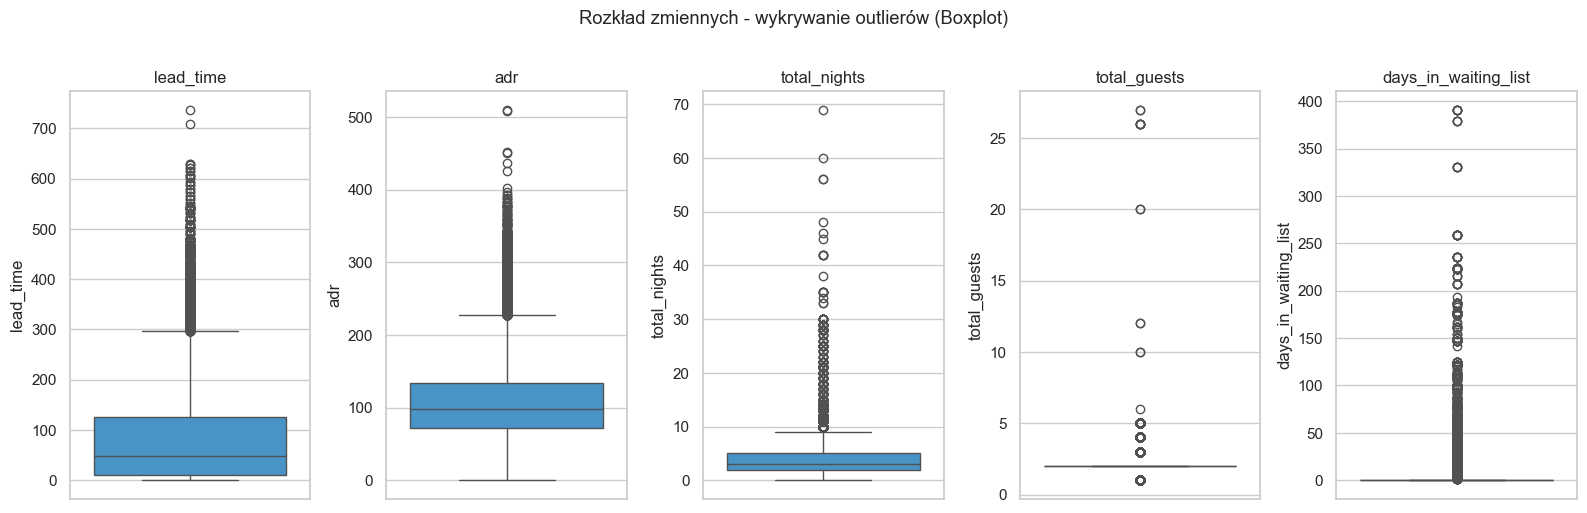


📊 Podsumowanie outlierów (metoda IQR):


,Zmienna,Liczba outlierów,% danych,Dolna granica,Górna granica
0,lead_time,2366,2.7%,-160.0,296.0
1,adr,2502,2.9%,-20.5,226.9
2,total_nights,2982,3.4%,-2.5,9.5
3,total_guests,30086,34.6%,2.0,2.0
4,days_in_waiting_list,842,1.0%,0.0,0.0



💡 Uwagi:
- lead_time: Długie rezerwacje z wyprzedzeniem są naturalne dla niektórych grup
- adr: Wysokie ceny mogą być luksusowymi pokojami lub apartamentami
- days_in_waiting_list: Większość rezerwacji nie ma listy oczekujących


In [4]:
# Funkcja do wykrywania outlierów metodą IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

# Analiza outlierów dla kluczowych zmiennych
outlier_cols = ['lead_time', 'adr', 'total_nights', 'total_guests', 'days_in_waiting_list']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))

outlier_summary = []
for i, col in enumerate(outlier_cols):
    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[i], color='#3498db')
    axes[i].set_title(f'{col}')
    
    # Oblicz outliers
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    pct = n_outliers / len(df) * 100
    outlier_summary.append({'Zmienna': col, 'Liczba outlierów': n_outliers, 
                            '% danych': f'{pct:.1f}%', 'Dolna granica': f'{lower:.1f}', 
                            'Górna granica': f'{upper:.1f}'})

plt.suptitle('Rozkład zmiennych - wykrywanie outlierów (Boxplot)', y=1.02)
plt.tight_layout()
plt.show()

# Tabela podsumowująca
print('\n📊 Podsumowanie outlierów (metoda IQR):')
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print('\n💡 Uwagi:')
print('- lead_time: Długie rezerwacje z wyprzedzeniem są naturalne dla niektórych grup')
print('- adr: Wysokie ceny mogą być luksusowymi pokojami lub apartamentami')
print('- days_in_waiting_list: Większość rezerwacji nie ma listy oczekujących')

---
## 4. Rozkład zmiennych kategorycznych

Jak wyglądają proporcje w zmiennych kategorycznych?

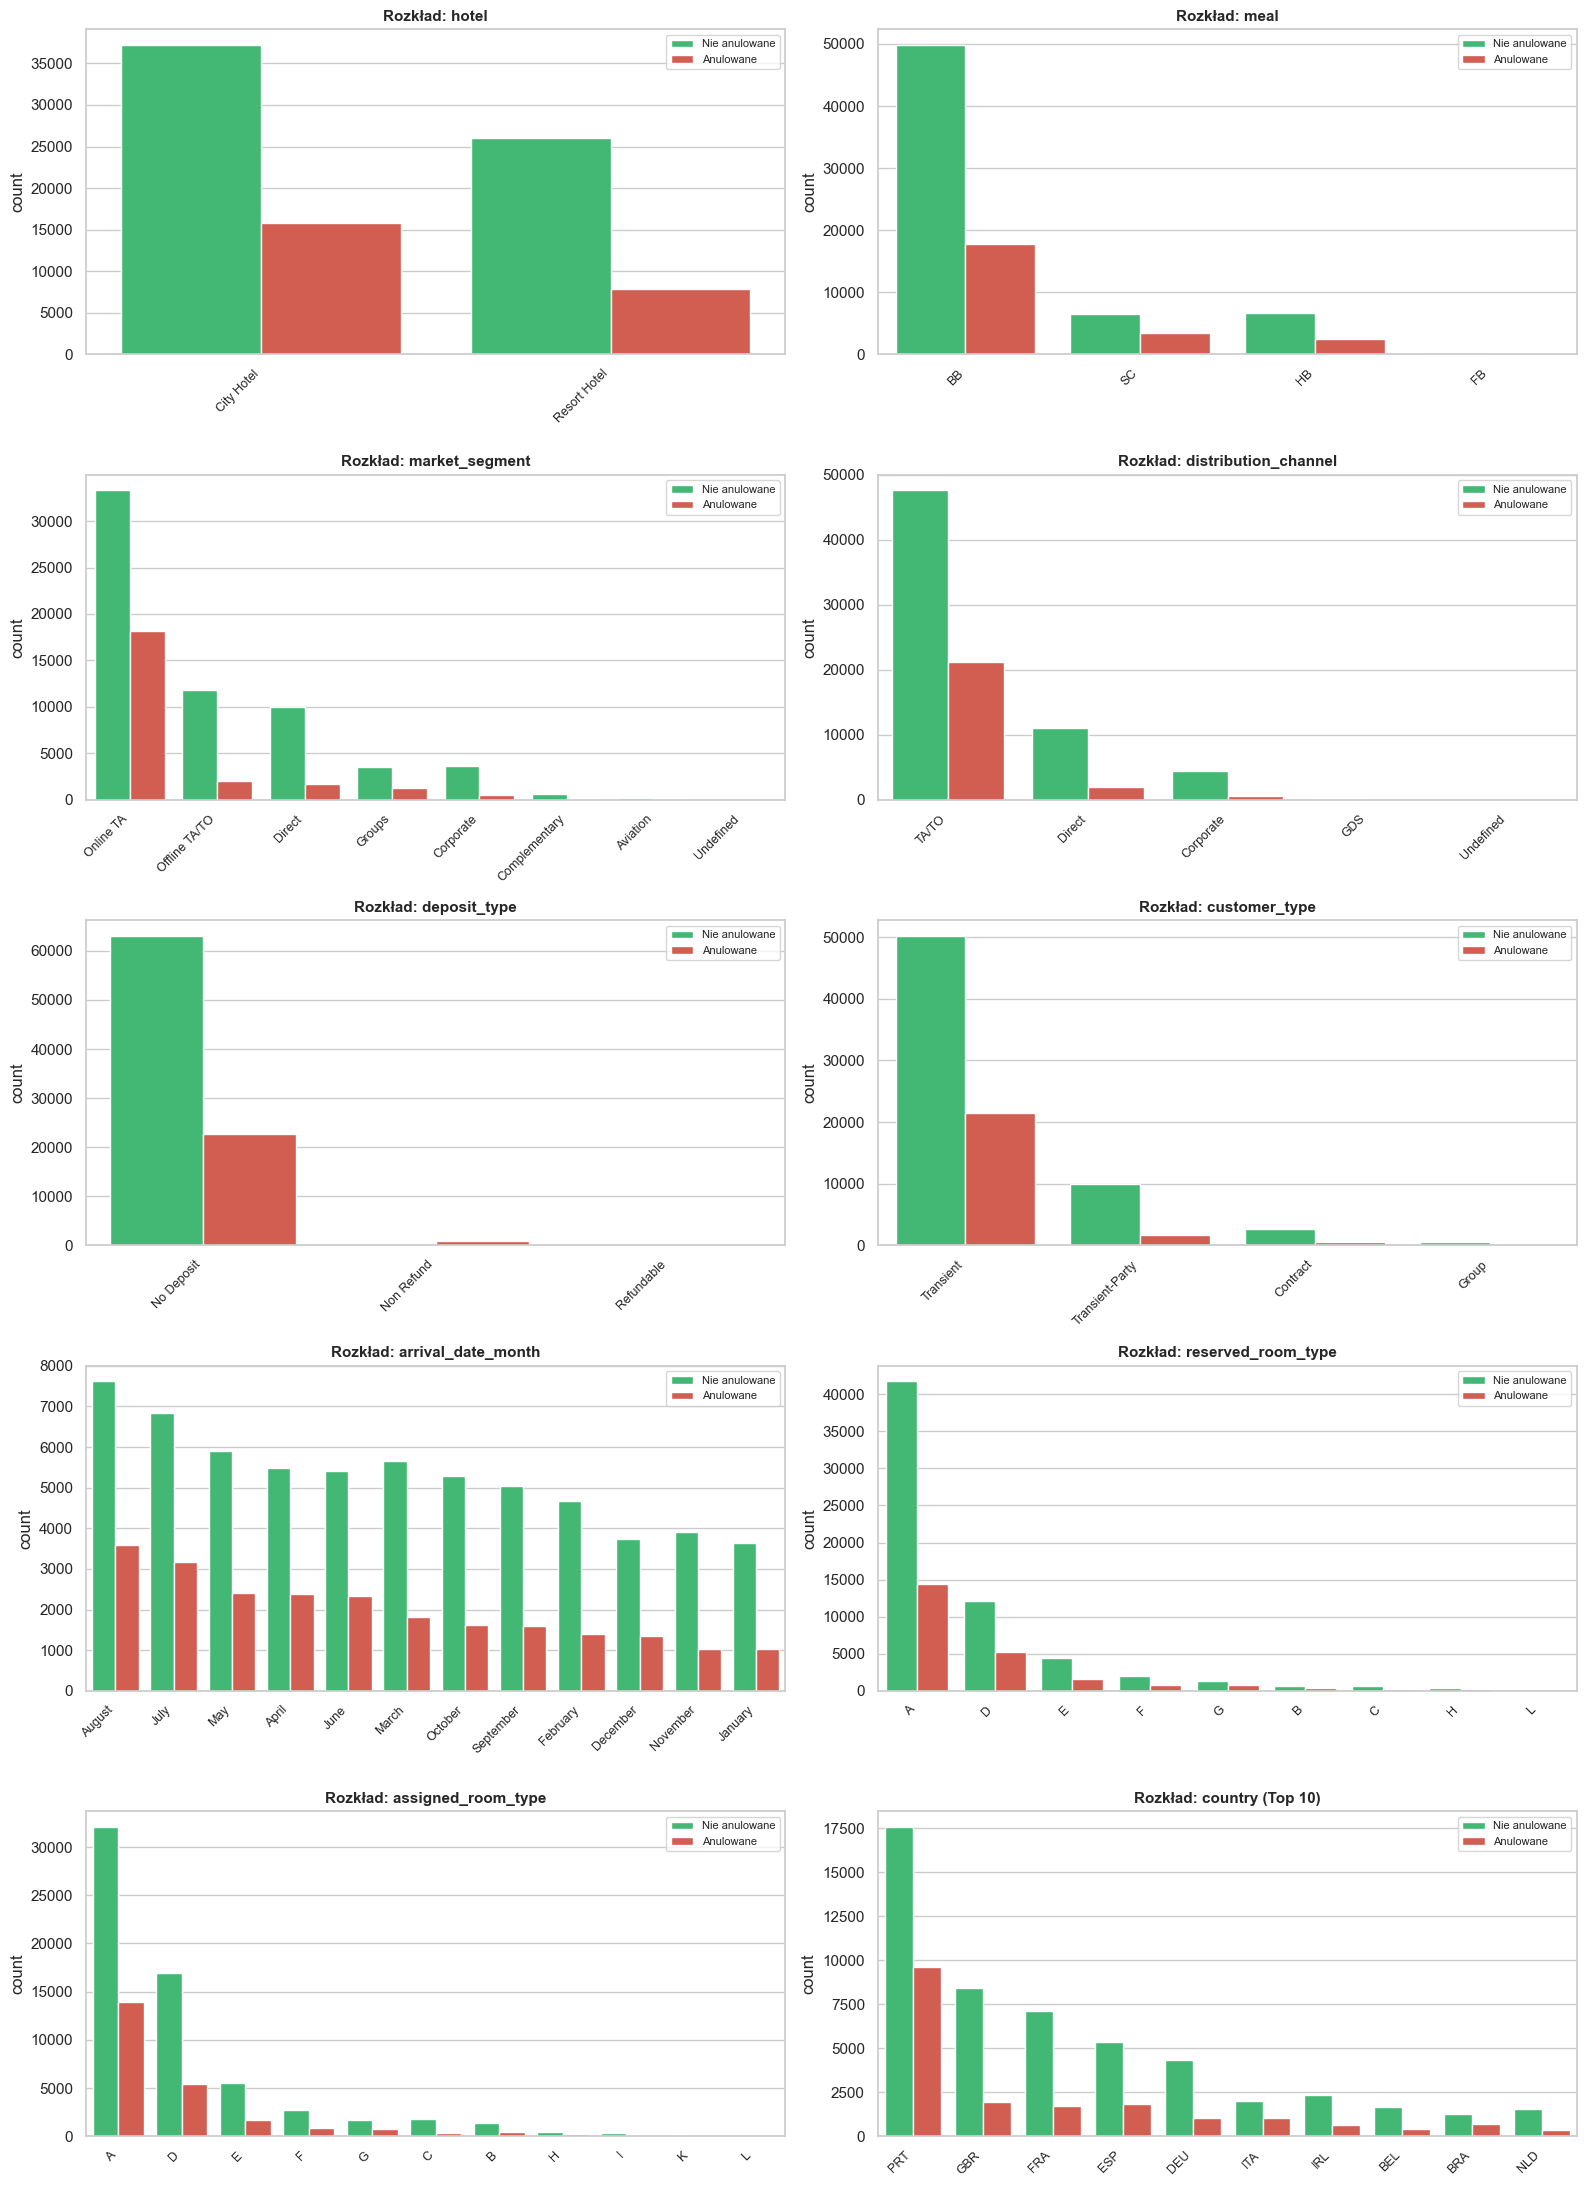


📊 Liczność kategorii:

hotel:
hotel
City Hotel      53098
Resort Hotel    33869

meal:
meal
BB    67710
SC     9860
HB     9043
FB      354

market_segment:
market_segment
Online TA        51437
Offline TA/TO    13809
Direct           11768
Groups            4843
Corporate         4190
Complementary      692
Aviation           226
Undefined            2

distribution_channel:
distribution_channel
TA/TO        68800
Direct       12933
Corporate     5050
GDS            179
Undefined        5

deposit_type:
deposit_type
No Deposit    85844
Non Refund     1016
Refundable      107

customer_type:
customer_type
Transient          71731
Transient-Party    11564
Contract            3134
Group                538

arrival_date_month:
arrival_date_month
August       11222
July         10024
May           8306
April         7871
June          7735
March         7471
October       6897
September     6647
February      6069
December      5096
November      4957
January       4672

reserved_room_typ

In [5]:
# Zmienne kategoryczne - wszystkie (country ograniczone do top 10)
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
            'deposit_type', 'customer_type', 'arrival_date_month',
            'reserved_room_type', 'assigned_room_type', 'country']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Dla country ograniczamy do top 10
    if col == 'country':
        top_vals = df[col].value_counts().head(10).index
        data_subset = df[df[col].isin(top_vals)]
        order = top_vals
        title = f'Rozkład: {col} (Top 10)'
    else:
        data_subset = df
        order = df[col].value_counts().index
        title = f'Rozkład: {col}'
    
    sns.countplot(data=data_subset, x=col, hue='is_canceled', ax=ax, 
                  palette=['#2ecc71', '#e74c3c'], order=order)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.legend(['Nie anulowane', 'Anulowane'], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print('\n📊 Liczność kategorii:')
for col in cat_cols:
    if col == 'country':
        print(f'\n{col} (top 10):')
        print(df[col].value_counts().head(10).to_string())
    else:
        print(f'\n{col}:')
        print(df[col].value_counts().to_string())

---
## 5. Analiza sezonowości anulowań

Czy pewne miesiące mają wyższy wskaźnik anulowań? Jak wygląda to w podziale na typ hotelu?

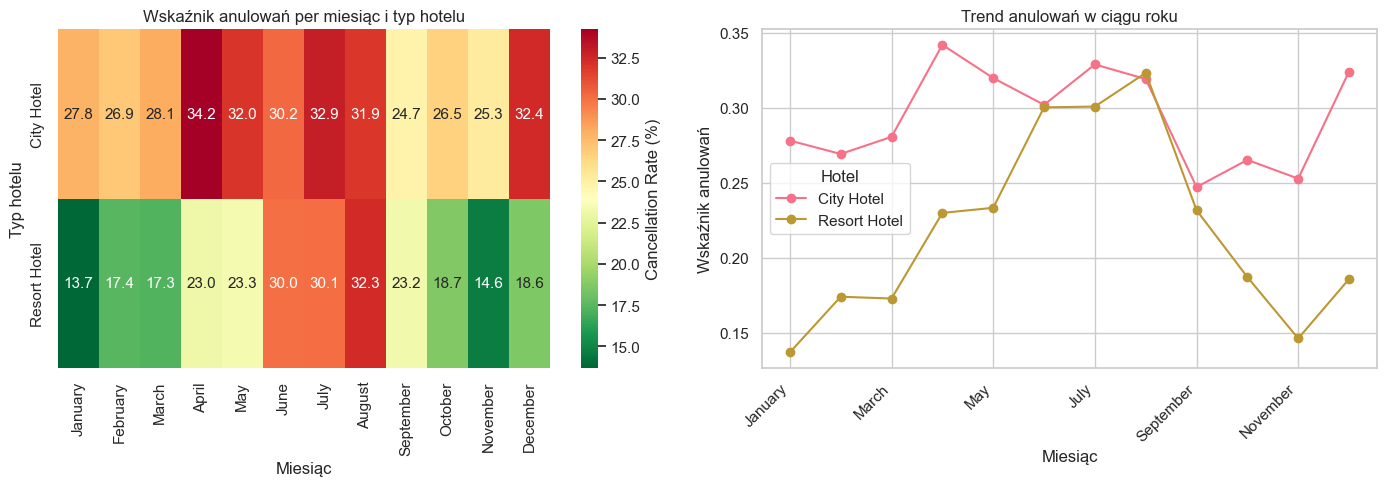


📊 Wnioski:
- Najwyższy wskaźnik anulowań: 34.2% w ('April', 'City Hotel')
- Najniższy wskaźnik anulowań: 13.7% w ('January', 'Resort Hotel')


In [6]:
# Kolejność miesięcy
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Wskaźnik anulowań per miesiąc i typ hotelu
monthly_cancel = df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().unstack()
monthly_cancel = monthly_cancel.reindex(month_order)

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa
sns.heatmap(monthly_cancel.T * 100, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            ax=axes[0], cbar_kws={'label': 'Cancellation Rate (%)'})
axes[0].set_title('Wskaźnik anulowań per miesiąc i typ hotelu')
axes[0].set_xlabel('Miesiąc')
axes[0].set_ylabel('Typ hotelu')

# Liniowy
monthly_cancel.plot(marker='o', ax=axes[1])
axes[1].set_title('Trend anulowań w ciągu roku')
axes[1].set_ylabel('Wskaźnik anulowań')
axes[1].set_xlabel('Miesiąc')
axes[1].legend(title='Hotel')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 Wnioski:")
print(f"- Najwyższy wskaźnik anulowań: {monthly_cancel.max().max()*100:.1f}% w {monthly_cancel.stack().idxmax()}")
print(f"- Najniższy wskaźnik anulowań: {monthly_cancel.min().min()*100:.1f}% w {monthly_cancel.stack().idxmin()}")

---
## 6. Lead time vs Cancellation - Czy wcześniejsze rezerwacje są częściej anulowane?

Intuicyjnie: im wcześniej zarezerwowane, tym więcej czasu na zmianę planów.

/var/folders/5b/89qrx6cj06149fgvcgrxz1180000gn/T/ipykernel_39116/3057681215.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_canceled', y='lead_time', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
/var/folders/5b/89qrx6cj06149fgvcgrxz1180000gn/T/ipykernel_39116/3057681215.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Nie anulowane', 'Anulowane'])


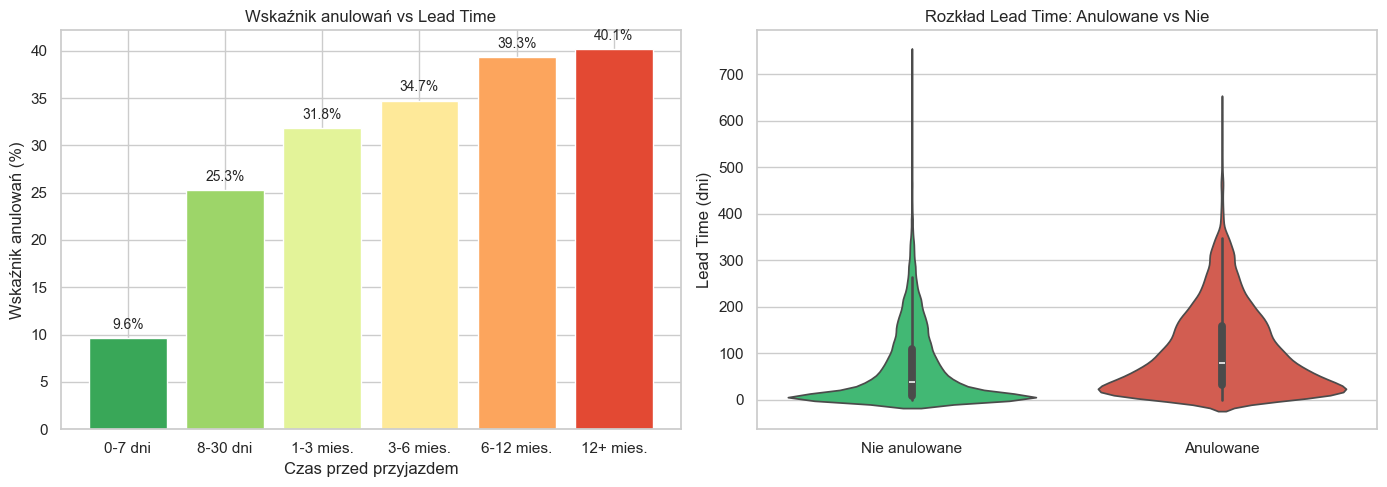


📊 Wnioski:
- Rezerwacje 12+ mies. wcześniej mają 40.1% anulowań
- Rezerwacje last-minute (0-7 dni) mają tylko 9.6% anulowań


In [7]:
# Podział lead_time na kategorie
bins = [0, 7, 30, 90, 180, 365, 800]
labels = ['0-7 dni', '8-30 dni', '1-3 mies.', '3-6 mies.', '6-12 mies.', '12+ mies.']
df['lead_time_category'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

# Analiza
lead_cancel = df.groupby('lead_time_category', observed=True).agg(
    cancellation_rate=('is_canceled', 'mean'),
    count=('is_canceled', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('RdYlGn_r', len(lead_cancel))
bars = axes[0].bar(lead_cancel['lead_time_category'], 
                   lead_cancel['cancellation_rate'] * 100, 
                   color=colors)
axes[0].set_title('Wskaźnik anulowań vs Lead Time')
axes[0].set_ylabel('Wskaźnik anulowań (%)')
axes[0].set_xlabel('Czas przed przyjazdem')
for bar, val in zip(bars, lead_cancel['cancellation_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val*100:.1f}%', ha='center', fontsize=10)

# Violin plot - rozkład lead_time
sns.violinplot(data=df, x='is_canceled', y='lead_time', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Rozkład Lead Time: Anulowane vs Nie')
axes[1].set_xticklabels(['Nie anulowane', 'Anulowane'])
axes[1].set_ylabel('Lead Time (dni)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("\n📊 Wnioski:")
print(f"- Rezerwacje 12+ mies. wcześniej mają {lead_cancel.iloc[-1]['cancellation_rate']*100:.1f}% anulowań")
print(f"- Rezerwacje last-minute (0-7 dni) mają tylko {lead_cancel.iloc[0]['cancellation_rate']*100:.1f}% anulowań")

---
## 7. Wpływ typu depozytu na anulowanie

Czy wymaganie depozytu zmniejsza liczbę anulowań?

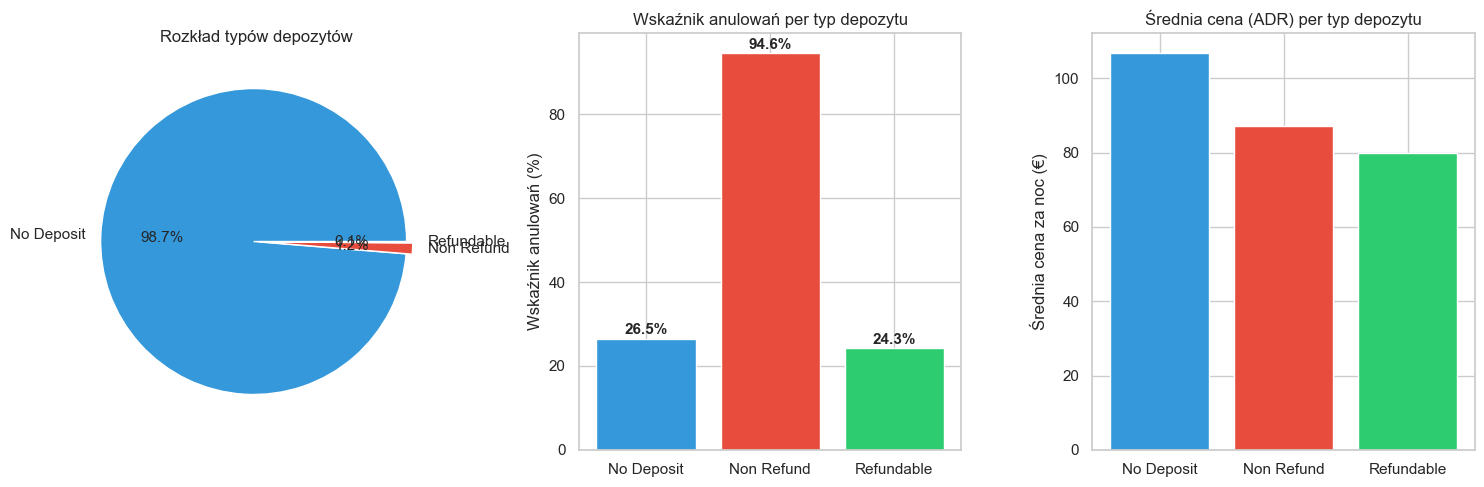


📊 Wnioski:
- 'Non Refund' ma najwyższy wskaźnik anulowań (94.6%) - paradoks!
- 'No Deposit' ma wskaźnik 26.5%
- Możliwe wyjaśnienie: Non-refund często dotyczy ryzykownych rezerwacji


In [8]:
# Analiza depozytu
deposit_analysis = df.groupby('deposit_type').agg(
    count=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean'),
    avg_adr=('adr', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Liczba rezerwacji per typ depozytu
colors_deposit = {'No Deposit': '#3498db', 'Non Refund': '#e74c3c', 'Refundable': '#2ecc71'}
axes[0].pie(deposit_analysis['count'], labels=deposit_analysis['deposit_type'], 
            autopct='%1.1f%%', colors=[colors_deposit.get(x, '#95a5a6') for x in deposit_analysis['deposit_type']],
            explode=[0.02]*len(deposit_analysis))
axes[0].set_title('Rozkład typów depozytów')

# Wskaźnik anulowań per typ
bars = axes[1].bar(deposit_analysis['deposit_type'], 
                   deposit_analysis['cancellation_rate'] * 100,
                   color=[colors_deposit.get(x, '#95a5a6') for x in deposit_analysis['deposit_type']])
axes[1].set_title('Wskaźnik anulowań per typ depozytu')
axes[1].set_ylabel('Wskaźnik anulowań (%)')
for bar, val in zip(bars, deposit_analysis['cancellation_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

# Średnia cena per typ
axes[2].bar(deposit_analysis['deposit_type'], deposit_analysis['avg_adr'],
            color=[colors_deposit.get(x, '#95a5a6') for x in deposit_analysis['deposit_type']])
axes[2].set_title('Średnia cena (ADR) per typ depozytu')
axes[2].set_ylabel('Średnia cena za noc (€)')

plt.tight_layout()
plt.show()

print("\n📊 Wnioski:")
non_refund = deposit_analysis[deposit_analysis['deposit_type'] == 'Non Refund']['cancellation_rate'].values[0]
no_deposit = deposit_analysis[deposit_analysis['deposit_type'] == 'No Deposit']['cancellation_rate'].values[0]
print(f"- 'Non Refund' ma najwyższy wskaźnik anulowań ({non_refund*100:.1f}%) - paradoks!")
print(f"- 'No Deposit' ma wskaźnik {no_deposit*100:.1f}%")
print("- Możliwe wyjaśnienie: Non-refund często dotyczy ryzykownych rezerwacji")

---
## 8. Analiza segmentu rynku i kanału dystrybucji

Które segmenty klientów i kanały dystrybucji generują najwięcej anulowań?

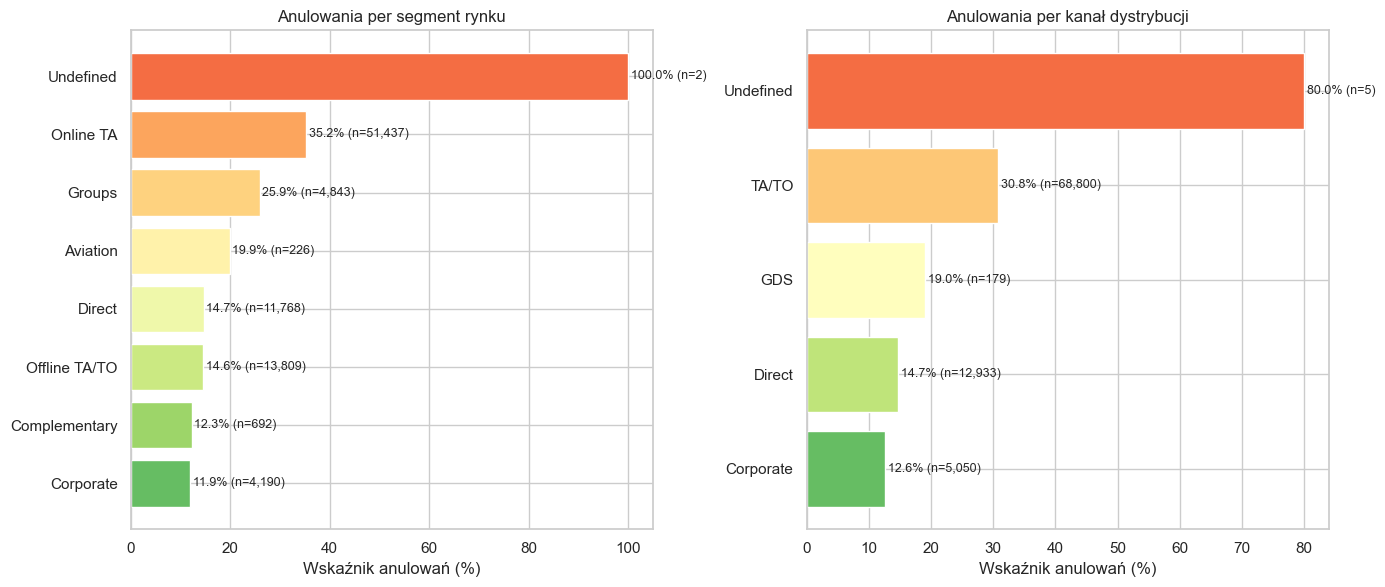


📊 Wnioski:
- Najgorszy segment: 'Undefined' z 100.0% anulowań
- Najlepszy segment: 'Corporate' z 11.9% anulowań


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Market segment
segment_cancel = df.groupby('market_segment')['is_canceled'].agg(['mean', 'count']).reset_index()
segment_cancel = segment_cancel.sort_values('mean', ascending=True)

colors_seg = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(segment_cancel)))
bars1 = axes[0].barh(segment_cancel['market_segment'], segment_cancel['mean'] * 100, color=colors_seg)
axes[0].set_xlabel('Wskaźnik anulowań (%)')
axes[0].set_title('Anulowania per segment rynku')
for bar, (_, row) in zip(bars1, segment_cancel.iterrows()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{row["mean"]*100:.1f}% (n={row["count"]:,})', va='center', fontsize=9)

# Distribution channel
channel_cancel = df.groupby('distribution_channel')['is_canceled'].agg(['mean', 'count']).reset_index()
channel_cancel = channel_cancel.sort_values('mean', ascending=True)

colors_ch = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(channel_cancel)))
bars2 = axes[1].barh(channel_cancel['distribution_channel'], channel_cancel['mean'] * 100, color=colors_ch)
axes[1].set_xlabel('Wskaźnik anulowań (%)')
axes[1].set_title('Anulowania per kanał dystrybucji')
for bar, (_, row) in zip(bars2, channel_cancel.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{row["mean"]*100:.1f}% (n={row["count"]:,})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Wnioski:")
worst_segment = segment_cancel.iloc[-1]
best_segment = segment_cancel.iloc[0]
print(f"- Najgorszy segment: '{worst_segment['market_segment']}' z {worst_segment['mean']*100:.1f}% anulowań")
print(f"- Najlepszy segment: '{best_segment['market_segment']}' z {best_segment['mean']*100:.1f}% anulowań")

---
## 9. Profil klienta anulującego - porównanie cech

Jakie są charakterystyczne cechy rezerwacji, które zostają anulowane?

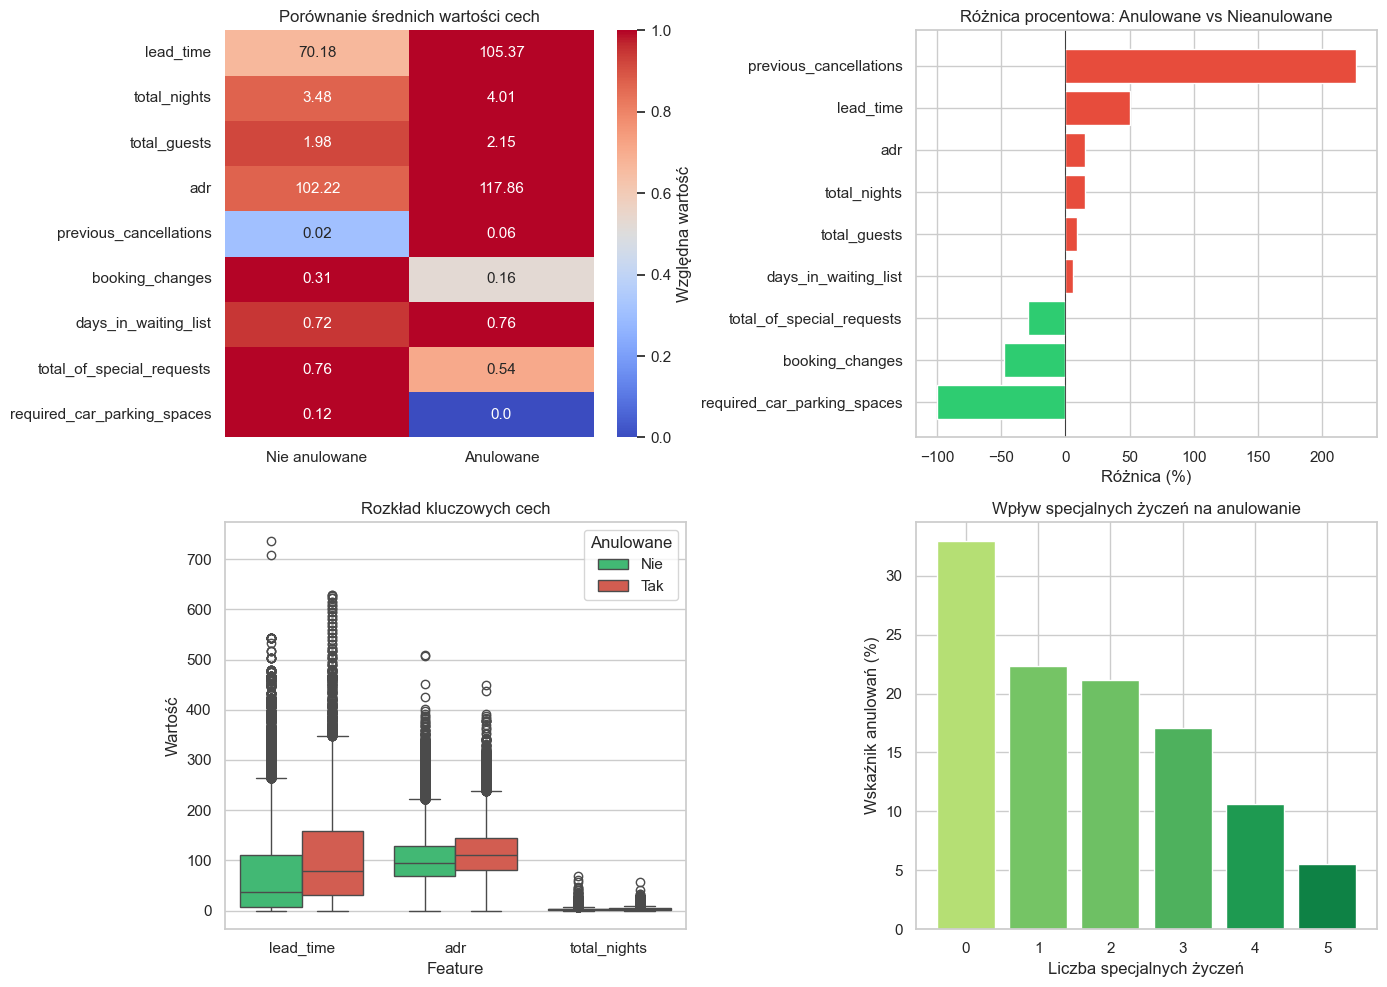


📊 Wnioski:
                             Nie anulowane   Anulowane  Różnica (%)
lead_time                        70.183581  105.365899         50.1
total_nights                      3.484024    4.012970         15.2
total_guests                      1.980908    2.152693          8.7
adr                             102.215920  117.861159         15.3
previous_cancellations            0.018681    0.060934        226.2
booking_changes                   0.309301    0.161999        -47.6
days_in_waiting_list              0.717273    0.758327          5.7
total_of_special_requests         0.760883    0.538973        -29.2
required_car_parking_spaces       0.116324    0.000000       -100.0

- Klienci anulujący mają znacznie dłuższy lead_time
- Klienci anulujący mają więcej poprzednich anulowań
- Klienci ze specjalnymi życzeniami rzadziej anulują


In [10]:
# Porównanie średnich wartości między anulowanymi i nieanulowanymi
numeric_cols = ['lead_time', 'total_nights', 'total_guests', 'adr', 
                'previous_cancellations', 'booking_changes', 'days_in_waiting_list',
                'total_of_special_requests', 'required_car_parking_spaces']

comparison = df.groupby('is_canceled')[numeric_cols].mean().T
comparison.columns = ['Nie anulowane', 'Anulowane']
comparison['Różnica (%)'] = ((comparison['Anulowane'] - comparison['Nie anulowane']) / comparison['Nie anulowane'] * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmapa porównania
comparison_normalized = comparison[['Nie anulowane', 'Anulowane']].apply(lambda x: x / x.max(), axis=1)
sns.heatmap(comparison_normalized, annot=comparison[['Nie anulowane', 'Anulowane']].round(2), 
            fmt='', cmap='coolwarm', ax=axes[0, 0], cbar_kws={'label': 'Względna wartość'})
axes[0, 0].set_title('Porównanie średnich wartości cech')

# Top różnice
diff_sorted = comparison['Różnica (%)'].sort_values()
colors_diff = ['#e74c3c' if x > 0 else '#2ecc71' for x in diff_sorted]
axes[0, 1].barh(diff_sorted.index, diff_sorted.values, color=colors_diff)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Różnica (%)')
axes[0, 1].set_title('Różnica procentowa: Anulowane vs Nieanulowane')

# Boxplot dla kluczowych cech
df_melted = df[['is_canceled', 'lead_time', 'adr', 'total_nights']].melt(
    id_vars='is_canceled', var_name='Feature', value_name='Value')
df_melted['is_canceled'] = df_melted['is_canceled'].map({0: 'Nie', 1: 'Tak'})

sns.boxplot(data=df_melted, x='Feature', y='Value', hue='is_canceled', ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Rozkład kluczowych cech')
axes[1, 0].set_ylabel('Wartość')
axes[1, 0].legend(title='Anulowane')

# Special requests vs cancellation
special_req = df.groupby('total_of_special_requests')['is_canceled'].mean()
axes[1, 1].bar(special_req.index, special_req.values * 100, color=plt.cm.RdYlGn_r(special_req.values))
axes[1, 1].set_xlabel('Liczba specjalnych życzeń')
axes[1, 1].set_ylabel('Wskaźnik anulowań (%)')
axes[1, 1].set_title('Wpływ specjalnych życzeń na anulowanie')

plt.tight_layout()
plt.show()

print("\n📊 Wnioski:")
print(comparison[['Nie anulowane', 'Anulowane', 'Różnica (%)']].to_string())
print("\n- Klienci anulujący mają znacznie dłuższy lead_time")
print("- Klienci anulujący mają więcej poprzednich anulowań")
print("- Klienci ze specjalnymi życzeniami rzadziej anulują")

---
## Podsumowanie kluczowych odkryć

| Czynnik | Wpływ na anulowanie |
|---------|---------------------|
| Lead time | ↑ Dłuższy = więcej anulowań |
| Specjalne życzenia | ↓ Więcej życzeń = mniej anulowań |
| Typ depozytu | Non-refund paradoksalnie = więcej anulowań |
| Segment | Groups = najwyższy wskaźnik |
| Sezonowość | Lato = więcej anulowań |

In [11]:
# Czyszczenie tymczasowej kolumny
if 'lead_time_category' in df.columns:
    df = df.drop(columns=['lead_time_category'])